In [1]:
import pandas as pd
import json
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import chi2_contingency
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [2]:
#Load Data
df = pd.read_csv("../data/preprocessed_healthcare_dataset.csv")
df.head()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Billing Amount,Admission Type,Discharge Date,Medication,Test Results,Length of Stay
0,bobby jackson,30,1,5,2,2024-01-31,26612,34469,18856.281306,2,2024-02-02,3,2,2
1,leslie terry,62,1,0,5,2019-08-20,33648,20829,33643.327287,1,2019-08-26,1,1,6
2,danny smith,76,0,1,5,2022-09-22,37828,10300,27955.096079,1,2022-10-07,0,2,15
3,andrew watts,28,0,6,3,2020-11-18,22511,17147,37909.782410,0,2020-12-18,1,0,30
4,adrienne bell,43,0,2,2,2022-09-19,21259,38411,14238.317814,2,2022-10-09,4,0,20


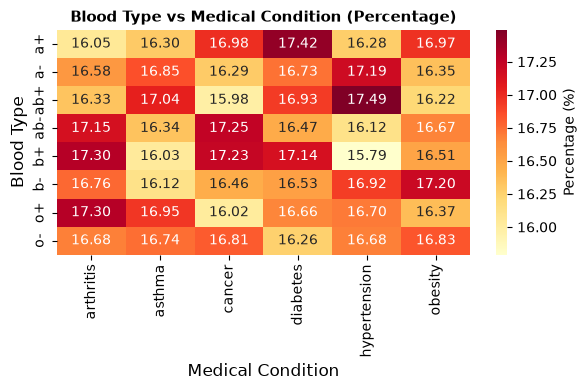

In [3]:
# We now start EDA
# Show Association between blood type and medical condition
# Blood type columns are like Blood Type_b- and medical condition columns are like Medical Condition_Diabetes
# Create A contingency table for blood type and medical condition
# Get blood type and medical condition columns
contingency = pd.crosstab(df['Blood Type'], df['Medical Condition'])
with open('../data/encodings/Blood Type_mapping.json', 'r') as f:
    blood_type_mapping = json.load(f)
with open('../data/encodings/Medical Condition_mapping.json', 'r') as f:
    medical_condition_mapping = json.load(f)
    
blood_type_mapping = {v: k for k, v in blood_type_mapping.items()}
medical_condition_mapping = {v: k for k, v in medical_condition_mapping.items()}
contingency.index = contingency.index.map(blood_type_mapping)
contingency.columns = contingency.columns.map(medical_condition_mapping)

contingency_pct = (contingency.div(contingency.sum(axis=1), axis=0) * 100).round(2)

# Create heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(contingency_pct, annot=True, fmt='.2f', cmap='YlOrRd', cbar_kws={'label': 'Percentage (%)'})
plt.title('Blood Type vs Medical Condition (Percentage)', fontsize=11, fontweight='bold')
plt.xlabel('Medical Condition', fontsize=12)
plt.ylabel('Blood Type', fontsize=12)
plt.tight_layout()
plt.show()

In [4]:
# Perform Chi-Square Test
chi2, p_value, dof, expected_freq = chi2_contingency(contingency)

# Calculate Cramér's V
n = contingency.sum().sum()
min_dim = min(contingency.shape[0] - 1, contingency.shape[1] - 1)
cramers_v = np.sqrt(chi2 / (n * min_dim))

# Print results
print("CHI-SQUARE TEST OF INDEPENDENCE")
print("="*80)
print(f"χ² Statistic: {chi2:.4f}")
print(f"p-value: {p_value:.6f}")
print(f"Degrees of Freedom: {dof}")
print(f"Cramér's V (Effect Size): {cramers_v:.4f}")
print("="*80)

# Interpretation
if p_value < 0.05:
    print(f"\n✓ SIGNIFICANT: Blood type and medical condition ARE associated (p < 0.05)")
else:
    print(f"\n✗ NOT SIGNIFICANT: They are independent (p >= 0.05)")

# Effect size
if cramers_v < 0.1:
    effect = "Negligible"
elif cramers_v < 0.3:
    effect = "Small"
elif cramers_v < 0.5:
    effect = "Medium"
else:
    effect = "Large"
    
print(f"Effect Size: {effect}")

CHI-SQUARE TEST OF INDEPENDENCE
χ² Statistic: 34.8181
p-value: 0.476858
Degrees of Freedom: 35
Cramér's V (Effect Size): 0.0113

✗ NOT SIGNIFICANT: They are independent (p >= 0.05)
Effect Size: Negligible


In [5]:
# Analyze length of stay for each medical condition
results = []

for condition_encoded in sorted(df['Medical Condition'].unique()):
    condition_name = medical_condition_mapping[condition_encoded]
    condition_data = df[df['Medical Condition'] == condition_encoded]['Length of Stay']
    
    results.append({
        'Condition': condition_name,
        'Count': len(condition_data),
        'Mean Stay': round(condition_data.mean(), 2),
        'Median': round(condition_data.median(), 2),
        'Std Dev': round(condition_data.std(), 2),
        'Min Stay': int(condition_data.min()),
        'Max Stay': int(condition_data.max())
    })

# Create and sort table
results_df = pd.DataFrame(results).sort_values('Mean Stay', ascending=False).reset_index(drop=True)

print(results_df.to_string(index=False))

   Condition  Count  Mean Stay  Median  Std Dev  Min Stay  Max Stay
      asthma   9095      15.68    16.0     8.71         1        30
   arthritis   9218      15.50    15.0     8.61         1        30
      cancer   9140      15.50    15.0     8.67         1        30
     obesity   9146      15.45    15.0     8.69         1        30
hypertension   9151      15.44    15.0     8.64         1        30
    diabetes   9216      15.43    15.0     8.66         1        30


In [6]:
# Load doctor mapping
with open("../data/encodings/Doctor_mapping.json", 'r') as f:
    doctor_mapping = json.load(f)
reverse_doctor_map = {v: k for k, v in doctor_mapping.items()}

# Decode doctor column to names
df['Doctor'] = df['Doctor'].map(reverse_doctor_map)

# Total patients per doctor
total_patients = df.groupby('Doctor').size().rename('Total Patients')

# Cross-tab of doctor x condition counts, normalized to row percentages
counts = pd.crosstab(df['Doctor'], df['Medical Condition'])
pct = counts.div(counts.sum(axis=1), axis=0) * 100
pct = pct.round(2)

# Rename encoded condition columns to their real names
pct = pct.rename(columns=medical_condition_mapping)

# Combine with total patients, sort by patient count
doctor_df = pct.join(total_patients).reset_index()
doctor_df = doctor_df[['Doctor', 'Total Patients'] + [c for c in doctor_df.columns if c not in ('Doctor', 'Total Patients')]]
doctor_df = doctor_df.sort_values('Total Patients', ascending=False).reset_index(drop=True)
df['Doctor'] = df['Doctor'].map(doctor_mapping)
print(doctor_df.to_string(index=False))

                      Doctor  Total Patients  arthritis  asthma  cancer  diabetes  hypertension  obesity
               michael smith              27      14.81   14.81   18.52     22.22         25.93     3.70
                  john smith              22      36.36    9.09    9.09      4.55         18.18    22.73
                robert smith              21      14.29   23.81   19.05      9.52          9.52    23.81
             michael johnson              20      15.00   20.00   30.00     15.00         10.00    10.00
                 james smith              20      10.00   15.00   10.00     20.00         25.00    20.00
                 david smith              19      21.05   26.32    5.26     26.32          5.26    15.79
              robert johnson              19      21.05   26.32    5.26     15.79         15.79    15.79
            michael williams              18      27.78   16.67   11.11     16.67         16.67    11.11
               matthew smith              17      17.65


MODEL 1: WITH ALL FEATURES (Doctor, Hospital, Blood Type)

Features: ['Age', 'Gender', 'Blood Type', 'Medical Condition', 'Doctor', 'Hospital', 'Admission Type', 'Medication', 'Test Results']
Target: Length of Stay
Data shape: (54966, 9)

MODEL 1 PERFORMANCE

Training Set:
  R² Score: 0.0003
  RMSE: 8.6588 days
  MAE: 7.5107 days

Testing Set:
  R² Score: -0.0004
  RMSE: 8.6682 days
  MAE: 7.5148 days

Model explains -0.04% of the variance
Average prediction error: ±7.51 days

Top 10 Most Important Features:
          Feature  Coefficient
           Gender     0.095551
Medical Condition    -0.036835
   Admission Type    -0.036734
     Test Results     0.028085
       Medication     0.022634
              Age     0.004911
       Blood Type     0.000767
         Hospital    -0.000004
           Doctor     0.000003

VISUALIZATION: MODEL 1 - LINEAR REGRESSION


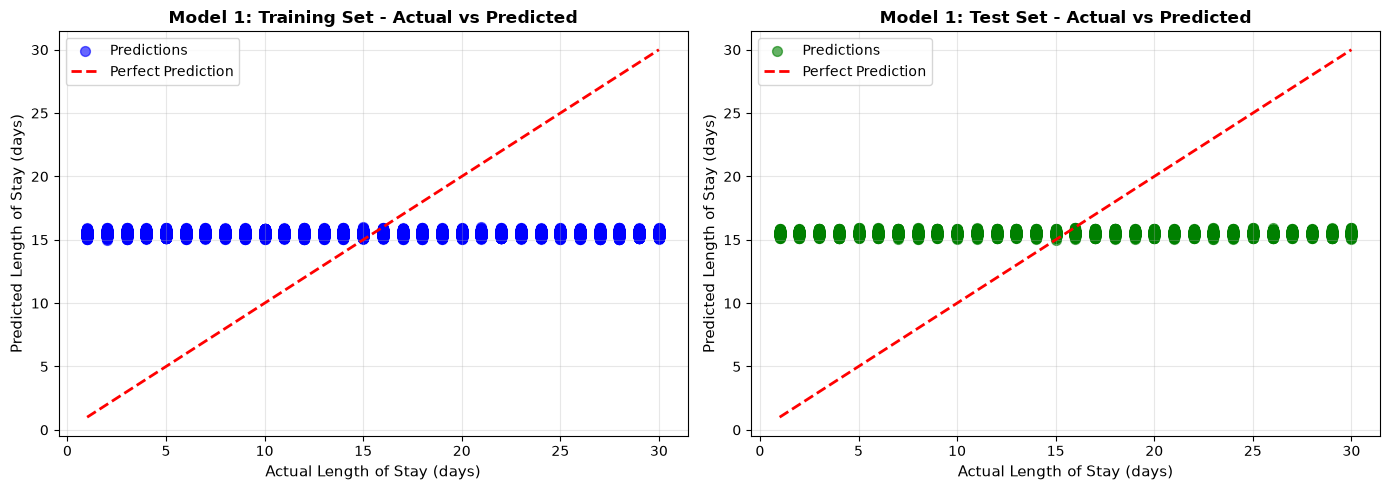


MODEL 2: WITHOUT Doctor, Hospital, Blood Type

Features: ['Age', 'Gender', 'Medical Condition', 'Admission Type', 'Medication', 'Test Results']
Target: Length of Stay
Data shape: (54966, 6)

MODEL 2 PERFORMANCE

Training Set:
  R² Score: 0.0002
  RMSE: 8.6590 days
  MAE: 7.5110 days

Testing Set:
  R² Score: -0.0003
  RMSE: 8.6681 days
  MAE: 7.5151 days

Model explains -0.03% of the variance
Average prediction error: ±7.52 days

Top 10 Most Important Features:
          Feature  Coefficient
           Gender     0.094736
Medical Condition    -0.037062
   Admission Type    -0.037013
     Test Results     0.028323
       Medication     0.022724
              Age     0.004905


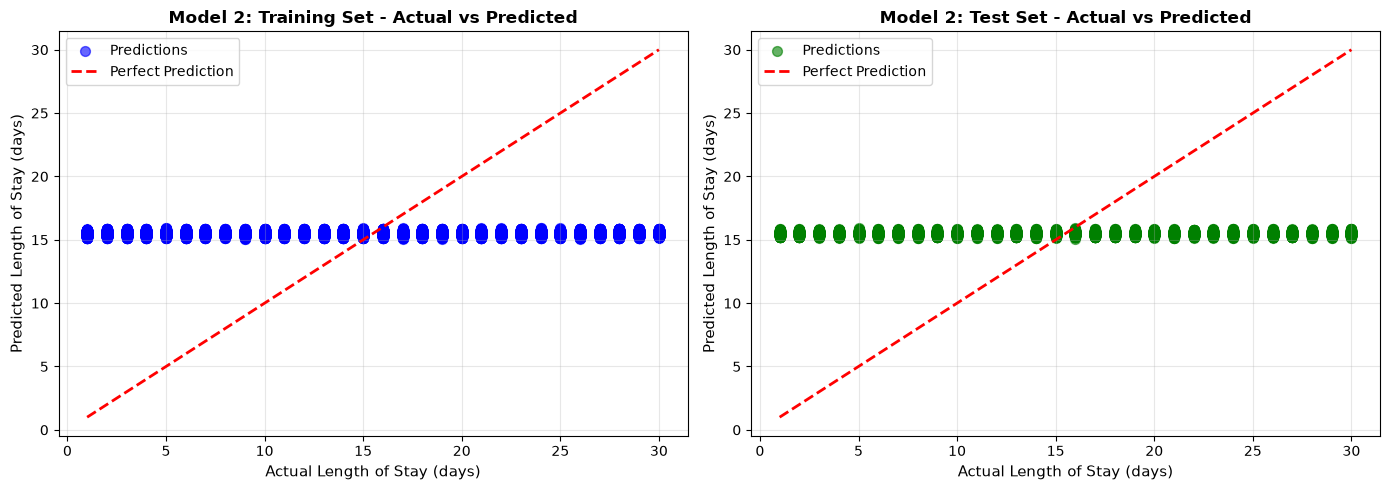


MODEL COMPARISON

Model 1 (All Features):
  Test R²: -0.0003
  Test MAE: 7.5151 days

Model 2 (Without Doctor/Hospital/Blood Type):
  Test R²: -0.0003
  Test MAE: 7.5151 days

(Compare the metrics above to see which model performs better)


In [9]:
# Predict Length of Stay using Features being used: Age Gender Blood Type Medical Condition Admission Type Medication Test Results Hospital Doctor
# Build Linear regression model
# Prepare features and target

#get all the columns that starts with Gender_
# Prepare features and target

print("\n" + "="*80)
print("MODEL 1: WITH ALL FEATURES (Doctor, Hospital, Blood Type)")
print("="*80)

# Prepare features and target
y = df['Length of Stay']
X = df.drop(['Name', 'Date of Admission', 'Discharge Date', 'Length of Stay', 'Billing Amount'], axis=1)

print("\nFeatures:", X.columns.tolist())
print("Target: Length of Stay")
print(f"Data shape: {X.shape}")

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
model1 = LinearRegression()
model1.fit(X_train, y_train)

# Make predictions
y_train_pred = model1.predict(X_train)
y_test_pred = model1.predict(X_test)

# Evaluate
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
train_mae = mean_absolute_error(y_train, y_train_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)

print("\n" + "="*60)
print("MODEL 1 PERFORMANCE")
print("="*60)
print(f"\nTraining Set:")
print(f"  R² Score: {train_r2:.4f}")
print(f"  RMSE: {train_rmse:.4f} days")
print(f"  MAE: {train_mae:.4f} days")

print(f"\nTesting Set:")
print(f"  R² Score: {test_r2:.4f}")
print(f"  RMSE: {test_rmse:.4f} days")
print(f"  MAE: {test_mae:.4f} days")

print(f"\nModel explains {test_r2*100:.2f}% of the variance")
print(f"Average prediction error: ±{test_mae:.2f} days")
print("="*60)

# Feature importance
coef_df = pd.DataFrame({'Feature': X.columns, 'Coefficient': model1.coef_})
coef_df['Abs'] = coef_df['Coefficient'].abs()
coef_df = coef_df.sort_values('Abs', ascending=False)

print("\nTop 10 Most Important Features:")
print(coef_df[['Feature', 'Coefficient']].head(10).to_string(index=False))


print("\n" + "="*80)
print("VISUALIZATION: MODEL 1 - LINEAR REGRESSION")
print("="*80)

# Create figure with subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Actual vs Predicted (Training Set)
axes[0].scatter(y_train, y_train_pred, alpha=0.6, s=50, color='blue', label='Predictions')
axes[0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Length of Stay (days)', fontsize=11)
axes[0].set_ylabel('Predicted Length of Stay (days)', fontsize=11)
axes[0].set_title('Model 1: Training Set - Actual vs Predicted', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Actual vs Predicted (Test Set)
axes[1].scatter(y_test, y_test_pred, alpha=0.6, s=50, color='green', label='Predictions')
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
axes[1].set_xlabel('Actual Length of Stay (days)', fontsize=11)
axes[1].set_ylabel('Predicted Length of Stay (days)', fontsize=11)
axes[1].set_title('Model 1: Test Set - Actual vs Predicted', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================================================
# MODEL 2: WITHOUT Doctor, Hospital, Blood Type
# ============================================================================

print("\n" + "="*80)
print("MODEL 2: WITHOUT Doctor, Hospital, Blood Type")
print("="*80)

# Prepare features and target (drop Doctor, Hospital, Blood Type columns)
y = df['Length of Stay']
X = df.drop(['Name', 'Date of Admission', 'Discharge Date', 'Length of Stay', 'Billing Amount',
             'Doctor', 'Hospital', 'Blood Type'], axis=1)

print("\nFeatures:", X.columns.tolist())
print("Target: Length of Stay")
print(f"Data shape: {X.shape}")

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
model2 = LinearRegression()
model2.fit(X_train, y_train)

# Make predictions
y_train_pred = model2.predict(X_train)
y_test_pred = model2.predict(X_test)

# Evaluate
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
train_mae = mean_absolute_error(y_train, y_train_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)

print("\n" + "="*60)
print("MODEL 2 PERFORMANCE")
print("="*60)
print(f"\nTraining Set:")
print(f"  R² Score: {train_r2:.4f}")
print(f"  RMSE: {train_rmse:.4f} days")
print(f"  MAE: {train_mae:.4f} days")

print(f"\nTesting Set:")
print(f"  R² Score: {test_r2:.4f}")
print(f"  RMSE: {test_rmse:.4f} days")
print(f"  MAE: {test_mae:.4f} days")

print(f"\nModel explains {test_r2*100:.2f}% of the variance")
print(f"Average prediction error: ±{test_mae:.2f} days")
print("="*60)

# Feature importance
coef_df = pd.DataFrame({'Feature': X.columns, 'Coefficient': model2.coef_})
coef_df['Abs'] = coef_df['Coefficient'].abs()
coef_df = coef_df.sort_values('Abs', ascending=False)

print("\nTop 10 Most Important Features:")
print(coef_df[['Feature', 'Coefficient']].head(10).to_string(index=False))


# Create figure with subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Actual vs Predicted (Training Set)
axes[0].scatter(y_train, y_train_pred, alpha=0.6, s=50, color='blue', label='Predictions')
axes[0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Length of Stay (days)', fontsize=11)
axes[0].set_ylabel('Predicted Length of Stay (days)', fontsize=11)
axes[0].set_title('Model 2: Training Set - Actual vs Predicted', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Actual vs Predicted (Test Set)
axes[1].scatter(y_test, y_test_pred, alpha=0.6, s=50, color='green', label='Predictions')
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
axes[1].set_xlabel('Actual Length of Stay (days)', fontsize=11)
axes[1].set_ylabel('Predicted Length of Stay (days)', fontsize=11)
axes[1].set_title('Model 2: Test Set - Actual vs Predicted', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================================================
# MODEL COMPARISON
# ============================================================================

print("\n" + "="*80)
print("MODEL COMPARISON")
print("="*80)
print(f"\nModel 1 (All Features):")
print(f"  Test R²: {test_r2:.4f}")
print(f"  Test MAE: {test_mae:.4f} days")

print(f"\nModel 2 (Without Doctor/Hospital/Blood Type):")
print(f"  Test R²: {test_r2:.4f}")
print(f"  Test MAE: {test_mae:.4f} days")

print("\n(Compare the metrics above to see which model performs better)")
print("="*80)